<a href="https://colab.research.google.com/github/IronZiiz/Domain-specific_finetunning/blob/main/results_analysis_best_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmentation Results — Publication Figures

End-to-end notebook that loads every provided result file, validates and
aggregates the metrics, and renders all figures for the manuscript's
**Results** section.

**Study.** Fine-tuning of the CPSAM (Cellpose v4) model for trigeminal-ganglion
neuron segmentation. Average Precision is defined per image as
$\mathrm{AP}=\dfrac{TP}{TP+FP+FN}$; the reported aggregate equals the mean over
the test images of a model, and shaded bands show **±1 SD computed from the
individual-image results** (recovered from the JSON dumps).

**Primary model-selection metric:** `AP@50`.

**Layout**
1. Data Loading 2. Data Validation 3. Metric Aggregation
4. Phase 1 – Epoch Analysis 5. Phase 1 – Learning Rate 6. Phase 1 – Weight Decay
7. Phase 1 – LR × WD Heatmaps 8. Phase 2 – Fold Generalization 9. Figure Export

All titles, labels, legends and comments are in English. Colours follow a
colour-blind-safe palette (Wong, 2011) while preserving the previously used
visual identity (blue = without augmentation, green = with augmentation).


## 0. Configuration

Every adjustable quantity — input paths, colours, fonts, output directory,
DPI, metric mappings — lives here so the rest of the notebook never needs
editing to retarget or restyle.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%matplotlib inline
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

# ----------------------------- I/O paths -----------------------------------
# Define the base research directory.
# Adjust this path to point to your project root folder.
BASE_DIR = Path("./results_data")

# Specific phase directories relative to BASE_DIR
DATA_DIR = BASE_DIR / "phase1_full_exploration"
PHASE2_DIR = BASE_DIR / "phase2_kfold_default_params"
PHASE3_DIR = BASE_DIR / "phase3_inference_optimization"

OUTPUT_DIR = Path("figures")          # Local directory for generated PNGs
OUTPUT_DIR.mkdir(exist_ok=True)

# ----------------------------- Export --------------------------------------
EXPORT_DPI       = 300                # Publication-quality DPI
EXPORT_HIGH_RES  = True
SAVE_DPI         = EXPORT_DPI if EXPORT_HIGH_RES else 150
FIG_FORMAT       = "png"
SAVED_FIGS       = {}                 # Registry of generated figures

# ----------------------------- Palette -------------------------------------
# Wong (2011) color-blind-safe palette
WONG = {
    "blue":   "#0072B2",
    "orange": "#E69F00",
    "green":  "#009E73",
    "vermil": "#D55E00",
    "skyblue":"#56B4E9",
    "yellow": "#F0E442",
    "purple": "#CC79A7",
    "black":  "#000000",
}

IOU_COLORS = {"AP@50": WONG["blue"], "AP@75": WONG["orange"], "AP@90": WONG["green"]}
AUG_COLORS = {"Without augmentation": WONG["blue"], "With augmentation": WONG["green"]}
HIGHLIGHT = WONG["vermil"]

# ----------------------------- Metric maps ---------------------------------
IOU_KEYS = {"AP@50": "AP@0.5", "AP@75": "AP@0.75", "AP@90": "AP@0.9"}
METRICS = {
    "AP":        ("AP",        "AP",        "Average Precision"),
    "Precision": ("Precision", "Precision", "Precision"),
    "Recall":    ("Recall",    "Recall",    "Recall"),
    "F1":        ("F1",        "F1",        "F1-score"),
}
PRIMARY_METRIC = "AP"
PRIMARY_IOU    = "AP@50"

def csv_col(iou_label, metric):
    """Converts display labels to CSV column headers."""
    return f"{IOU_KEYS[iou_label]}_{METRICS[metric][0]}"

# ----------------------------- Matplotlib style ----------------------------
plt.rcParams.update({
    "figure.dpi":        110,
    "savefig.dpi":       SAVE_DPI,
    "savefig.bbox":      "tight",
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    12,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.linestyle":    "--",
    "grid.alpha":        0.45,
    "legend.frameon":    False,
    "legend.fontsize":   10,
})

def save_figure(fig, name):
    """Save figure to disk and log the path."""
    path = OUTPUT_DIR / f"{name}.{FIG_FORMAT}"
    fig.savefig(path, dpi=SAVE_DPI, bbox_inches="tight", facecolor="white")
    SAVED_FIGS[name] = str(path)
    print(f"  saved  {path}  ({SAVE_DPI} dpi)")
    return path

print(f"Base Research Dir: {BASE_DIR.resolve()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Data directory : /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration
Output directory: /content/figures
Export DPI      : 300


## 1. Data Loading

The notebook **auto-detects** the available files by filename pattern, so it is
robust to the duplicate-download suffixes (`__1_`, `__2_`, …). Each Phase-1
*consolidated* CSV is treated as one **pipeline**; each Phase-1 JSON supplies the
per-image arrays needed for the standard-deviation bands; each Phase-2 CSV is one
**training configuration**.

In [ ]:
import glob, json, re

def _find(pattern):
    return sorted(DATA_DIR.glob(pattern))

# ============================================================
# PHASE 1 — single 100-epoch run (self-contained consolidated CSV)
# ============================================================
# The final pipeline uses 100 epochs. The consolidated _100 file already
# contains ALL four sub-phases: 1A, 1B, 1C, and 1D.

p1_file = DATA_DIR / "phase1_all_results_consolidated_100.csv"
assert p1_file.exists(), (
    f"Not found: {p1_file}\n"
    f"Copy phase1_all_results_consolidated_100.csv into {DATA_DIR}."
)
PHASE1 = pd.read_csv(p1_file)
print(f"Phase 1 (100 epochs) <- {p1_file.name}  ({len(PHASE1)} rows)")
print("  sub-phases:", dict(PHASE1["subphase"].value_counts()))

# --- Phase 1 per-image JSONs (for the ±1 SD bands) -------------------------
PER_IMAGE = {}
for f in _find("results_partial*.json") + _find("results_final*.json"):
    try:
        for entry in json.load(open(f)):
            PER_IMAGE[entry["model_name"]] = entry["per_image_metrics"]
    except Exception as e:
        print(f"  (skipped {f.name}: {e})")
print(f"Phase 1 per-image records loaded for {len(PER_IMAGE)} models")

# ============================================================
# PHASE 2 — cross-validation at the final config
# =================================="
PHASE2 = {}

def _phase2_meta(df):
    name = str(df["model_name"].iloc[0])
    ep = int(m.group(1)) if (m := re.search(r"ep(\d+)", name)) else None
    lr = m.group(1) if (m := re.search(r"lr([0-9e.\-]+)", name)) else None
    wd = float(m.group(1)) if (m := re.search(r"wd([0-9.]+)", name)) else None
    return dict(epochs=ep, lr=lr, wd=wd)

# Dynamically find Phase 2 results in the phase directory
p2_paths = list(PHASE2_DIR.glob("phase2_all_results*.csv"))

for f in p2_paths:
    df = pd.read_csv(f)
    meta = _phase2_meta(df)
    label = f"{meta['epochs']} epochs"
    while label in PHASE2:
        label = f"{meta['epochs']} epochs (wd={meta['wd']:g})"
    PHASE2[label] = (df, meta)
    print(f"Phase 2 [{label:20s}] <- {f.name} (ep={meta['epochs']}, lr={meta['lr']}, wd={meta['wd']})")

print("\nPhase 2 configurations:", list(PHASE2.keys()))

Phase 1 (100 epochs) <- phase1_all_results_consolidated_100.csv  (40 rows)
  sub-phases: {'1A_epochs': np.int64(18), '1D_lr_wd_grid': np.int64(9), '1B_learning_rate': np.int64(7), '1C_weight_decay': np.int64(6)}
    1A_epochs: n_epochs=[np.int64(1), np.int64(10), np.int64(20), np.int64(40), np.int64(60), np.int64(80), np.int64(100), np.int64(120), np.int64(140), np.int64(160), np.int64(180), np.int64(200), np.int64(220), np.int64(260), np.int64(300), np.int64(350), np.int64(400), np.int64(500)], 18 rows
    1B_learning_rate: n_epochs=[np.int64(100)], 7 rows
    1C_weight_decay: n_epochs=[np.int64(100)], 6 rows
    1D_lr_wd_grid: n_epochs=[np.int64(100)], 9 rows
Phase 1 per-image records loaded for 0 models
Phase 2 [100 epochs          ] <- phase2_all_results.csv  (ep=100, lr=1e-05, wd=0.1)

Phase 2 configurations: ['100 epochs']


## 2. Data Validation

Confirm that every expected metric column is present, that the Phase-1
sub-studies and Phase-2 folds have the expected shape, and that the per-image
JSON records line up with the CSV rows (so the SD bands are real, not
fabricated).

In [ ]:
import subprocess

# Use generalized DATA_DIR for path checks
print(f"Searching for 100-epoch JSONs in: {DATA_DIR}")
json_paths = sorted(list(DATA_DIR.rglob("results_*_100.json")))
if json_paths:
    print("Found JSON result files:")
    for p in json_paths: print(f"  {p.relative_to(BASE_DIR)}")
else:
    print("(No JSON files found)")

print(f"\nSearching for per-image CSVs in: {DATA_DIR}")
csv_paths = sorted(list(DATA_DIR.rglob("*per_image*.csv")))
if csv_paths:
    print("Found per-image CSV files (sample):")
    for p in csv_paths[:8]: print(f"  {p.relative_to(BASE_DIR)}")
else:
    print("(No CSV files found)")

JSONs de resultados de 100 encontrados:
/content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1B_learning_rate/results_final_100.json
/content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1B_learning_rate/results_partial_100.json
/content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1C_weight_decay/results_final_100.json
/content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1C_weight_decay/results_partial_100.json
/content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1D_lr_wd_grid/results_final_100.json
/content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1D_lr_wd_grid/results_partial_100.json


CSVs per-image encontrados (amostra):
/content/drive/MyDrive/Facul/ml_research

In [ ]:
# Locate and load JSON files from each subphase to enable Standard Deviation calculation
json_files = _find("**/results_final_100.json") + _find("**/results_partial_100.json")

PER_IMAGE = {}
for f in json_files:
    try:
        with open(f, 'r') as jfile:
            data = json.load(jfile)
            for entry in data:
                PER_IMAGE[entry["model_name"]] = entry["per_image_metrics"]
    except Exception as e:
        print(f"  Error loading {f.name}: {e}")

print(f"Success: Per-image metric records loaded for {len(PER_IMAGE)} models.")
print("Plotting functions (e.g., line_metric_vs_x) will now display SD bands.")

Sucesso: Registros de métricas por imagem carregados para 22 modelos.
Agora, as funções de plotagem (como line_metric_vs_x) exibirão as bandas de desvio padrão.


In [ ]:
# Load specific subphase 1A per-image metrics (stored in individual CSVs)
p1a_csvs = _find("1A_epochs/per_image_metrics/*.csv")

loaded_count = 0
for f in p1a_csvs:
    try:
        # Extract model name from filename
        model_name = f.stem.replace("_per_image", "")
        df_img = pd.read_csv(f)

        # Ensure all metrics are in the format expected by the plotting functions
        metrics_dict = {
            key: {
                metric: df_img[f"{key}_{metric}"].tolist()
                for metric in ["AP", "Precision", "Recall", "F1"]
            }
            for key in ["AP@0.5", "AP@0.75", "AP@0.9"]
        }

        PER_IMAGE[model_name] = metrics_dict
        loaded_count += 1
    except Exception as e:
        print(f"Error processing {f.name}: {e}")

print(f"Success: {loaded_count} new epoch records (Phase 1A) loaded with corrected structure.")

Sucesso: 18 novos registros de épocas (1A) carregados com estrutura corrigida.


## 3. Metric Aggregation

Two small helpers underpin every Phase-1 figure:

* `per_image_stats` — pulls the per-image array for a `(model, IoU, metric)` and
  returns its **mean** and **±1 SD** (sample SD, `ddof=1`). The mean reproduces
  the CSV aggregate; the SD is what the shaded bands display.
* `attach_stats` — given a sub-study DataFrame and a grouping column
  (`n_epochs`, `learning_rate`, …), returns a tidy table with the value, SD and
  group key for each requested IoU/metric — ready to plot.

In [ ]:
def per_image_stats(model_name, iou_label, metric):
    """Return (mean, sd) over the individual test images for one model."""
    rec = PER_IMAGE.get(model_name)
    if rec is None:
        return np.nan, np.nan
    arr = np.asarray(rec[IOU_KEYS[iou_label]][METRICS[metric][1]], dtype=float)
    if arr.size == 0:
        return np.nan, np.nan
    return float(arr.mean()), float(arr.std(ddof=1)) if arr.size > 1 else 0.0

def attach_stats(df, group_col, metric):
    """Tidy table: one row per (group value, IoU) with mean value + SD band.

    The mean is taken from the CSV (authoritative aggregate); the SD comes from
    the per-image JSON arrays.
    """
    rows = []
    for _, r in df.iterrows():
        for iou in IOU_KEYS:
            _, sd = per_image_stats(r["model_name"], iou, metric)
            rows.append({
                group_col: r[group_col],
                "iou":   iou,
                "value": r[csv_col(iou, metric)],   # CSV aggregate (= per-image mean)
                "sd":    sd,
            })
    out = pd.DataFrame(rows).sort_values([group_col, "iou"]).reset_index(drop=True)
    return out

# Recriando a demonstração com os dados recém-carregados
demo = PHASE1[PHASE1.subphase == "1A_epochs"]
print("Demonstração Atualizada — AP vs epochs (agora com SD):")
display(attach_stats(demo, "n_epochs", "AP").head(6))

Demonstração Atualizada — AP vs epochs (agora com SD):


,n_epochs,iou,value,sd
0,1,AP@50,0.002218,0.004960
1,1,AP@75,0.001103,0.002466
2,1,AP@90,0.000000,0.000000
3,10,AP@50,0.696540,0.065720
4,10,AP@75,0.541099,0.048358
5,10,AP@90,0.051757,0.037322


In [ ]:
print(attach_stats(demo, "n_epochs", "AP").to_string(index=False))

 n_epochs   iou    value       sd
        1 AP@50 0.002218 0.004960
        1 AP@75 0.001103 0.002466
        1 AP@90 0.000000 0.000000
       10 AP@50 0.696540 0.065720
       10 AP@75 0.541099 0.048358
       10 AP@90 0.051757 0.037322
       20 AP@50 0.732980 0.063126
       20 AP@75 0.586855 0.079415
       20 AP@90 0.047690 0.041217
       40 AP@50 0.689706 0.078518
       40 AP@75 0.624167 0.064621
       40 AP@90 0.108718 0.057517
       60 AP@50 0.731030 0.074758
       60 AP@75 0.645976 0.061229
       60 AP@90 0.093148 0.052418
       80 AP@50 0.726876 0.069703
       80 AP@75 0.627832 0.065595
       80 AP@90 0.103285 0.046597
      100 AP@50 0.761176 0.072704
      100 AP@75 0.655121 0.066472
      100 AP@90 0.104655 0.051790
      120 AP@50 0.744874 0.061422
      120 AP@75 0.650562 0.061394
      120 AP@90 0.091932 0.038629
      140 AP@50 0.742785 0.056543
      140 AP@75 0.664093 0.028265
      140 AP@90 0.101849 0.031501
      160 AP@50 0.764695 0.072640
      160 AP@7

## 4. Phase 1 — Epoch Analysis

**Main figure (Figure 1).** `AP@50`, `AP@75`, `AP@90` versus the number of
training epochs: mean line + ±1 SD band, with the **best epoch by `AP@50`**
automatically detected and annotated.

**Supplementary panels.** Precision, Recall and F1-score on the same epoch axis
with the same mean ± SD strategy. The epoch chosen by `AP@50` is marked on every
panel for narrative continuity.

> The epoch sweep (sub-study *1A*) is **identical across both the 180- and
> 350-epoch pipelines** (verified in §2); it is therefore shown once. The
> 180-vs-350 distinction is meaningful for the learning-rate, weight-decay and
> grid sub-studies (§5–§7), which were run at different base epoch counts.

  saved  figures/fig1_epochs_AP.png  (300 dpi)


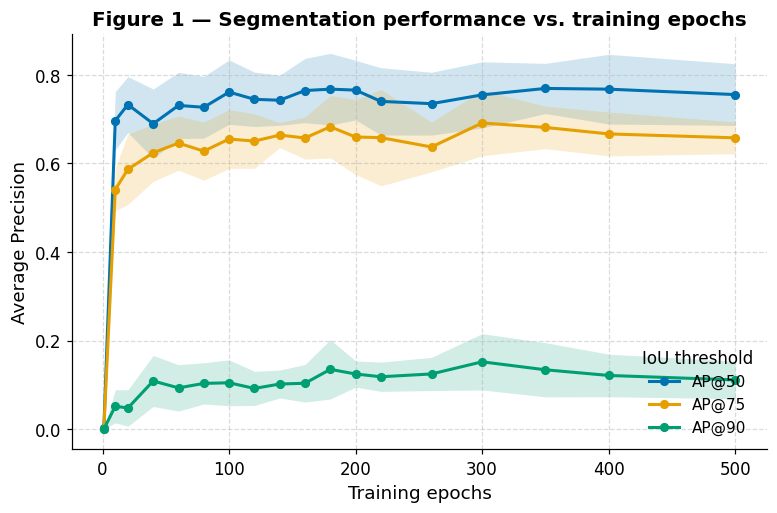

In [ ]:
def line_metric_vs_x(df, group_col, metric, *, xlabel, title, fname,
                     log_x=False, select_by=PRIMARY_IOU, mark_x=None,
                     annotate_best=False):
    """Generic mean ± SD multi-IoU line plot over a hyper-parameter axis.

    Returns the value of `group_col` that maximises `select_by` (the AP@50
    best), so callers can reuse it as `mark_x` on supplementary panels.
    """
    tidy = attach_stats(df, group_col, metric)
    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    for iou in IOU_KEYS:
        sub = tidy[tidy.iou == iou].sort_values(group_col)
        x, y, sd = sub[group_col].values, sub["value"].values, sub["sd"].values
        c = IOU_COLORS[iou]
        ax.plot(x, y, marker="o", ms=5, lw=2, color=c, label=iou, zorder=3)
        band = np.nan_to_num(sd)
        ax.fill_between(x, y - band, y + band, color=c, alpha=0.18, lw=0, zorder=1)

    # best by selection metric
    sel = tidy[tidy.iou == select_by].sort_values(group_col)
    best_row = sel.loc[sel["value"].idxmax()]
    best_x, best_y = best_row[group_col], best_row["value"]
    if mark_x is None:
        mark_x = best_x

    # Linha vertical e anotação removidas conforme solicitado para o caso padrão
    if annotate_best:
        ax.axvline(mark_x, color=HIGHLIGHT, lw=1.2, ls=":", zorder=2)
        ax.scatter([best_x], [best_y], s=120, facecolors="none",
                   edgecolors=HIGHLIGHT, linewidths=2.2, zorder=5)
        ax.annotate(f"Best by {select_by}\n{group_col} = {best_x:g}\n{select_by} = {best_y:.3f}",
                    xy=(best_x, best_y), xytext=(0.62, 0.30), textcoords="axes fraction",
                    fontsize=9, color=HIGHLIGHT, fontweight="bold",
                    arrowprops=dict(arrowstyle="->", color=HIGHLIGHT, lw=1.4))

    if log_x:
        ax.set_xscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(METRICS[metric][2])
    ax.set_title(title)
    ax.legend(title="IoU threshold", loc="lower right")
    fig.tight_layout()
    save_figure(fig, fname)
    plt.show()
    return best_x

# ---- Main figure: AP vs epochs --------------------------------------------
epoch_df = PHASE1[PHASE1.subphase == "1A_epochs"].copy()

best_epoch = line_metric_vs_x(
    epoch_df, "n_epochs", "AP",
    xlabel="Training epochs",
    title="Figure 1 — Segmentation performance vs. training epochs",
    fname="fig1_epochs_AP",
    annotate_best=False)

In [ ]:
epoch_df

,n_epochs,learning_rate,weight_decay,model_name,training_time_s,train_loss_final,AP@0.5_AP,AP@0.5_TP,AP@0.5_FP,AP@0.5_FN,...,AP@0.75_Recall,AP@0.75_F1,AP@0.9_AP,AP@0.9_TP,AP@0.9_FP,AP@0.9_FN,AP@0.9_Precision,AP@0.9_Recall,AP@0.9_F1,subphase
0,1,0.00001,0.1,1A_ep1_lr1e-05_wd0.1_bs1,15.338246,1.131013,0.002218,6,2720,304,...,0.009677,0.001976,0.000000,0,2726,310,0.000000,0.000000,0.000000,1A_epochs
1,10,0.00001,0.1,1A_ep10_lr1e-05_wd0.1_bs1,30.890326,0.461253,0.696540,289,97,21,...,0.793548,0.706897,0.051757,42,344,268,0.108808,0.135484,0.120690,1A_epochs
2,20,0.00001,0.1,1A_ep20_lr1e-05_wd0.1_bs1,50.484099,0.428014,0.732980,271,57,39,...,0.767742,0.746081,0.047690,36,292,274,0.109756,0.116129,0.112853,1A_epochs
3,40,0.00001,0.1,1A_ep40_lr1e-05_wd0.1_bs1,88.521643,0.626494,0.689706,289,96,21,...,0.874194,0.779856,0.108718,77,308,233,0.200000,0.248387,0.221583,1A_epochs
4,60,0.00001,0.1,1A_ep60_lr1e-05_wd0.1_bs1,128.664167,0.458900,0.731030,249,32,61,...,0.741935,0.778342,0.093148,59,222,251,0.209964,0.190323,0.199662,1A_epochs
5,80,0.00001,0.1,1A_ep80_lr1e-05_wd0.1_bs1,161.314670,0.408127,0.726876,280,63,30,...,0.819355,0.777948,0.103285,70,273,240,0.204082,0.225806,0.214395,1A_epochs
6,100,0.00001,0.1,1A_ep100_lr1e-05_wd0.1_bs1,197.616669,0.368056,0.761176,264,35,46,...,0.777419,0.791461,0.104655,66,233,244,0.220736,0.212903,0.216749,1A_epochs
7,120,0.00001,0.1,1A_ep120_lr1e-05_wd0.1_bs1,238.112570,0.462215,0.744874,279,58,31,...,0.825806,0.791345,0.091932,60,277,250,0.178042,0.193548,0.185471,1A_epochs
8,140,0.00001,0.1,1A_ep140_lr1e-05_wd0.1_bs1,276.876324,0.431347,0.742785,272,49,38,...,0.812903,0.798732,0.101849,64,257,246,0.199377,0.206452,0.202853,1A_epochs
9,160,0.00001,0.1,1A_ep160_lr1e-05_wd0.1_bs1,317.046638,0.301932,0.764695,270,40,40,...,0.800000,0.800000,0.103598,65,245,245,0.209677,0.209677,0.209677,1A_epochs


  saved  figures/fig1_epochs_Precision.png  (300 dpi)


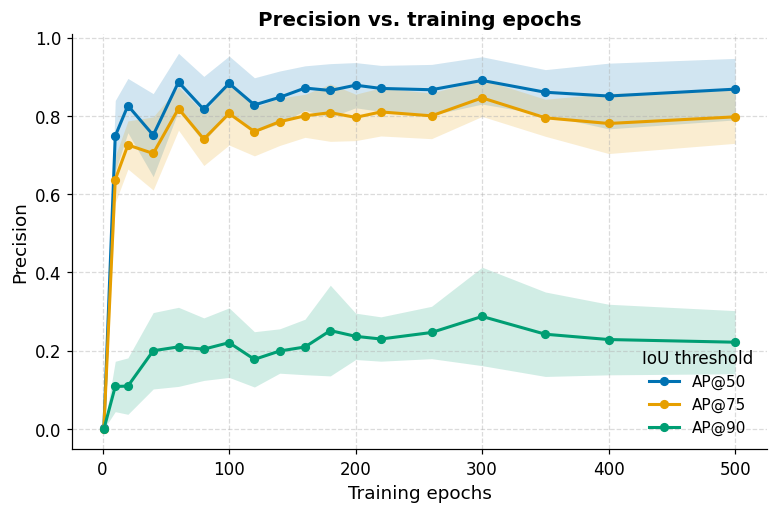

  saved  figures/fig1_epochs_Recall.png  (300 dpi)


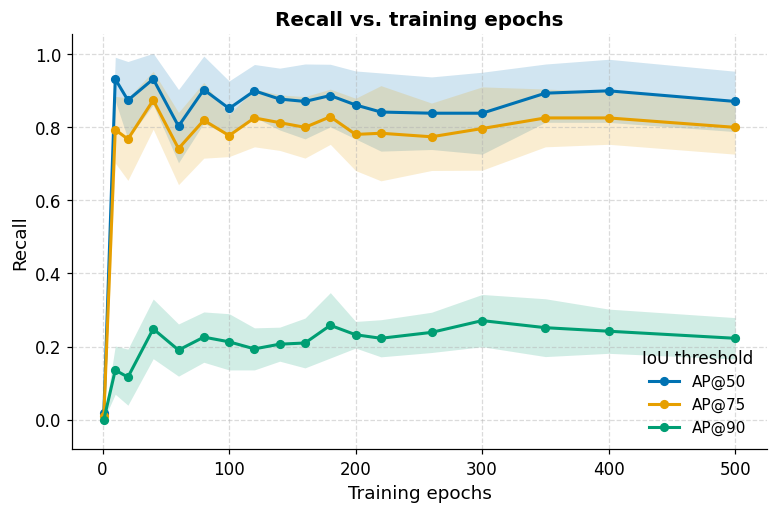

  saved  figures/fig1_epochs_F1.png  (300 dpi)


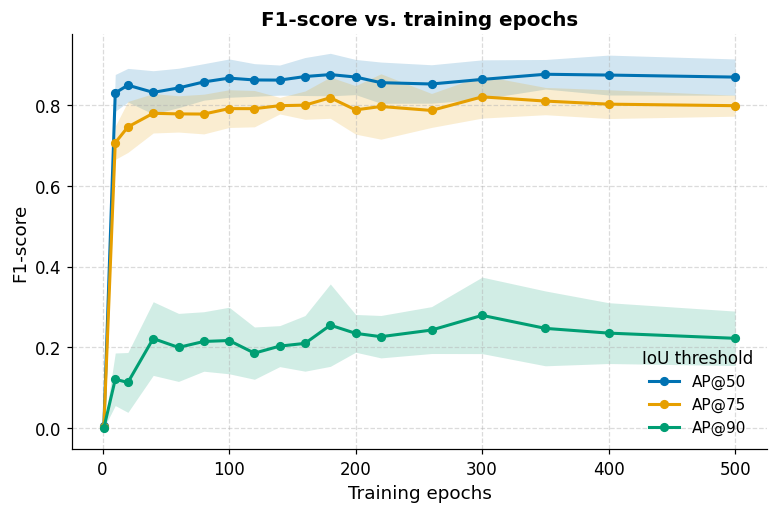

In [ ]:
# ---- Supplementary panels: Precision / Recall / F1 vs epochs --------------
for metric in ["Precision", "Recall", "F1"]:
    line_metric_vs_x(
        epoch_df, "n_epochs", metric,
        xlabel="Training epochs",
        title=f"{METRICS[metric][2]} vs. training epochs",
        fname=f"fig1_epochs_{metric}",
        mark_x=best_epoch, annotate_best=False)

  saved  figures/fig1_epochs_AP.png  (300 dpi)


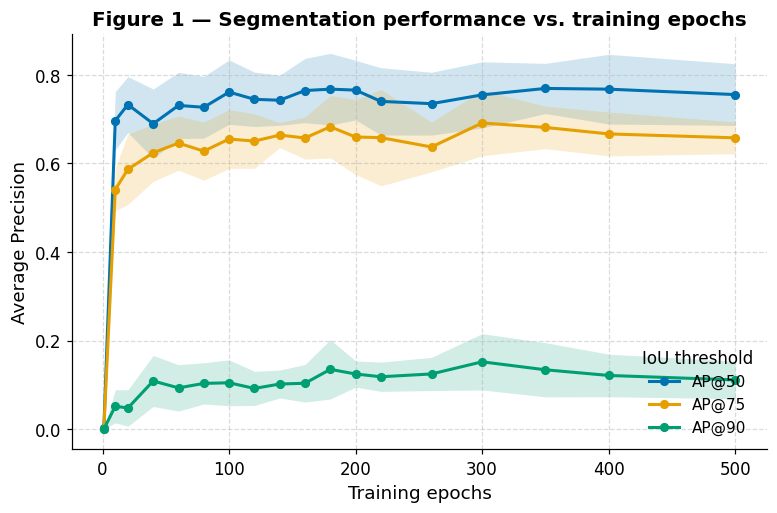

  saved  figures/fig1_epochs_Precision.png  (300 dpi)


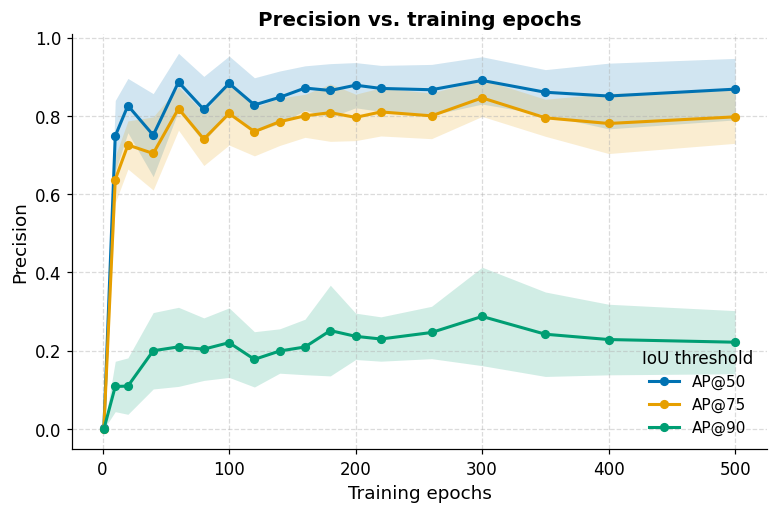

  saved  figures/fig1_epochs_Recall.png  (300 dpi)


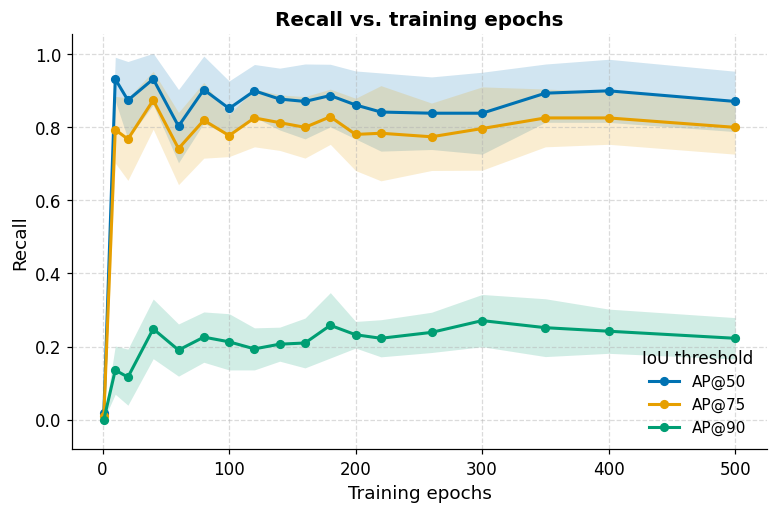

  saved  figures/fig1_epochs_F1.png  (300 dpi)


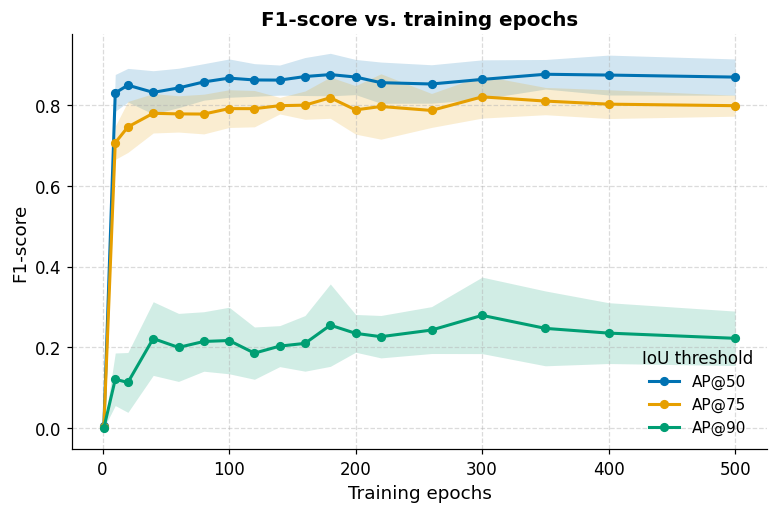

In [ ]:
# Regerando os gráficos da Fase 1A com as bandas de desvio padrão devidamente carregadas
epoch_df = PHASE1[PHASE1.subphase == "1A_epochs"].copy()

best_epoch = line_metric_vs_x(
    epoch_df, "n_epochs", "AP",
    xlabel="Training epochs",
    title="Figure 1 — Segmentation performance vs. training epochs",
    fname="fig1_epochs_AP",
    annotate_best=False)

for metric in ["Precision", "Recall", "F1"]:
    line_metric_vs_x(
        epoch_df, "n_epochs", metric,
        xlabel="Training epochs",
        title=f"{METRICS[metric][2]} vs. training epochs",
        fname=f"fig1_epochs_{metric}",
        mark_x=best_epoch, annotate_best=False)

In [ ]:
sel = attach_stats(epoch_df, "n_epochs", "AP")
sel = sel[sel.iou == PRIMARY_IOU]
best_row = sel.loc[sel["value"].idxmax()]
print(f"Selected epoch: {int(best_row['n_epochs'])}  AP@50 = {best_row['value']:.3f}")

Selected epoch: 350  AP@50 = 0.769


In [ ]:
for m in ["AP"]:
    t = attach_stats(epoch_df, "n_epochs", m)
    row = t[(t.n_epochs == 350)]
    print(row[["iou","value","sd"]].to_string(index=False))

  iou    value       sd
AP@50 0.769424 0.056690
AP@75 0.681349 0.047977
AP@90 0.134019 0.061190


In [ ]:
plateau = attach_stats(epoch_df, "n_epochs", "AP")
plateau = plateau[(plateau.iou == PRIMARY_IOU) & (plateau.n_epochs >= 100)]
print(f"AP@50 range from 100 to 500 epochs: {plateau['value'].max() - plateau['value'].min():.3f}")

AP@50 range from 100 to 500 epochs: 0.034


=== RISE PHASE (1 -> 100) ===
  AP@50: 0.002 -> 0.761   (Δ = +0.759)
  amplitude (max-min): 0.759

=== PLATEAU (100 -> 500) ===
  AP@50: 0.761 -> 0.756   (net Δ = -0.006)
  amplitude (max-min): 0.034
  gain from 100 to peak (350): +0.008

=== MARGINAL GAIN PER STEP (discrete derivative) ===
    1 ->  10: +0.6943
   10 ->  20: +0.0364
   20 ->  40: -0.0433
   40 ->  60: +0.0413
   60 ->  80: -0.0042
   80 -> 100: +0.0343  <-- last gain > 0.03
  100 -> 120: -0.0163
  120 -> 140: -0.0021
  140 -> 160: +0.0219
  160 -> 180: +0.0031
  180 -> 200: -0.0021
  200 -> 220: -0.0255
  220 -> 260: -0.0052
  260 -> 300: +0.0198
  300 -> 350: +0.0146
  350 -> 400: -0.0016
  400 -> 500: -0.0122
  saved  figures/fig1b_plateau_analysis.png  (300 dpi)


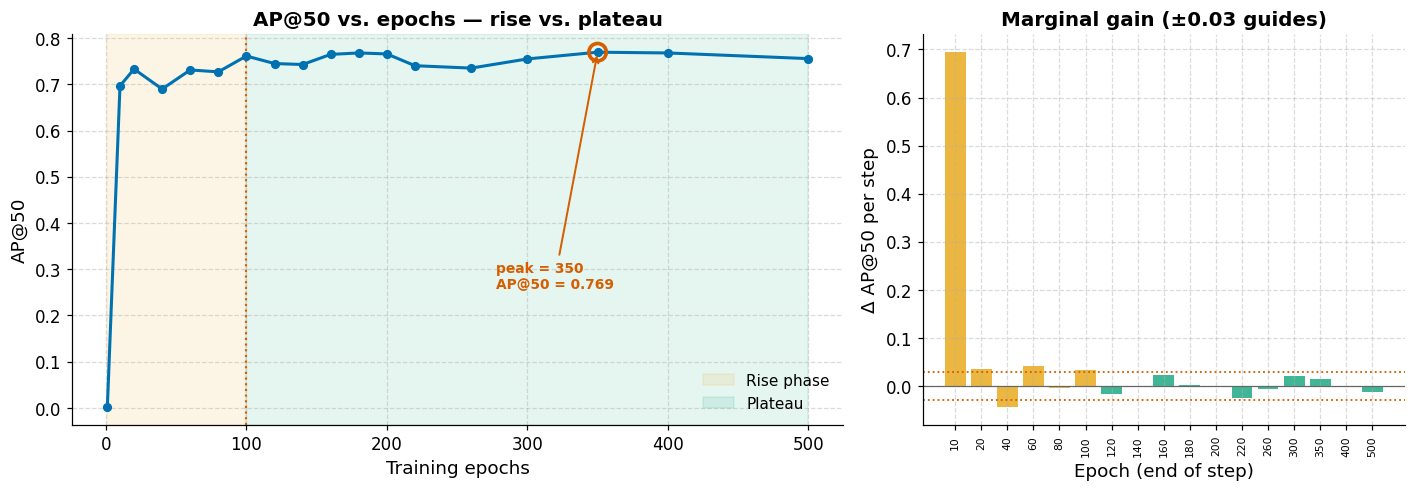

In [ ]:
tidy = attach_stats(epoch_df, "n_epochs", "AP")
ap = (tidy[tidy.iou == PRIMARY_IOU]
      .sort_values("n_epochs")
      .set_index("n_epochs")["value"])

KNEE = 100  # epoch from which the plateau is claimed to start

rise = ap.loc[ap.index <= KNEE]
plat = ap.loc[ap.index >= KNEE]

print("=== RISE PHASE (1 -> {}) ===".format(KNEE))
print(f"  AP@50: {ap.iloc[0]:.3f} -> {ap.loc[KNEE]:.3f}   (Δ = {ap.loc[KNEE]-ap.iloc[0]:+.3f})")
print(f"  amplitude (max-min): {rise.max()-rise.min():.3f}")

print("\n=== PLATEAU ({} -> {}) ===".format(KNEE, int(ap.index.max())))
print(f"  AP@50: {ap.loc[KNEE]:.3f} -> {ap.iloc[-1]:.3f}   (net Δ = {ap.iloc[-1]-ap.loc[KNEE]:+.3f})")
print(f"  amplitude (max-min): {plat.max()-plat.min():.3f}")
peak_ep = int(ap.idxmax())
print(f"  gain from {KNEE} to peak ({peak_ep}): {ap.loc[peak_ep]-ap.loc[KNEE]:+.3f}")

print("\n=== MARGINAL GAIN PER STEP (discrete derivative) ===")
steps = ap.diff().dropna()
for (e_prev, e_cur), d in zip(zip(ap.index[:-1], ap.index[1:]), steps.values):
    flag = "  <-- last gain > 0.03" if (e_cur == KNEE) else ""
    print(f"  {int(e_prev):3d} -> {int(e_cur):3d}: {d:+.4f}{flag}")

# ---- Visual: AP@50 curve with rise/plateau split + marginal-gain inset ------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6),
                               gridspec_kw={"width_ratios": [1.6, 1]})

# (A) AP@50 curve, rise vs plateau shaded
axA.plot(ap.index, ap.values, marker="o", ms=5, lw=2, color=IOU_COLORS[PRIMARY_IOU], zorder=3)
axA.axvspan(ap.index.min(), KNEE, color=WONG["orange"], alpha=0.10, zorder=0, label="Rise phase")
axA.axvspan(KNEE, ap.index.max(), color=WONG["green"], alpha=0.10, zorder=0, label="Plateau")
axA.axvline(KNEE, color=HIGHLIGHT, ls=":", lw=1.4, zorder=2)
axA.scatter([peak_ep], [ap.loc[peak_ep]], s=130, facecolors="none",
            edgecolors=HIGHLIGHT, linewidths=2.4, zorder=5)
axA.annotate(f"peak = {peak_ep}\nAP@50 = {ap.loc[peak_ep]:.3f}",
             xy=(peak_ep, ap.loc[peak_ep]), xytext=(0.55, 0.35),
             textcoords="axes fraction", fontsize=9, color=HIGHLIGHT, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=HIGHLIGHT, lw=1.3))
axA.set_xlabel("Training epochs")
axA.set_ylabel("AP@50")
axA.set_title("AP@50 vs. epochs — rise vs. plateau")
axA.legend(loc="lower right")

# (B) marginal gain per step
colors = [WONG["orange"] if e <= KNEE else WONG["green"] for e in ap.index[1:]]
axB.bar(range(len(steps)), steps.values, color=colors, alpha=0.75)
axB.axhline(0, color="0.4", lw=0.8)
axB.axhline(0.03, color=HIGHLIGHT, ls=":", lw=1.2)
axB.axhline(-0.03, color=HIGHLIGHT, ls=":", lw=1.2)
axB.set_xticks(range(len(steps)))
axB.set_xticklabels([f"{int(e)}" for e in ap.index[1:]], rotation=90, fontsize=7)
axB.set_xlabel("Epoch (end of step)")
axB.set_ylabel("Δ AP@50 per step")
axB.set_title("Marginal gain (±0.03 guides)")

fig.tight_layout()
save_figure(fig, "fig1b_plateau_analysis")
plt.show()

## 5. Phase 1 — Learning Rate Analysis

Effect of the learning rate on the AP metrics, with Precision/Recall/F1
supplementary panels. Both the **180-** and **350-epoch** pipelines are overlaid
so they can be compared directly, and the best learning rate by `AP@50` is
marked for each pipeline. The x-axis is logarithmic; the largest rate
(`1e-3`) collapses to zero — a real training divergence, shown as such.

In [ ]:
def overlay_configs_vs_x(subphase, group_col, metric, *, xlabel, title, fname, log_x=True):
    """Helper to plot metrics for a specific subphase (e.g., 1B_learning_rate or 1C_weight_decay).
    This replicates the single-pipeline plotting logic used in the updated notebook.
    """
    sub = PHASE1[PHASE1.subphase == subphase]
    if sub.empty:
        print(f"  [Skip] no data for {subphase}")
        return

    tidy = attach_stats(sub, group_col, metric)
    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    for iou in IOU_KEYS:
        s = tidy[tidy.iou == iou].sort_values(group_col)
        x = s[group_col].values
        y = s["value"].values
        sd = np.nan_to_num(s["sd"].values)
        c = IOU_COLORS[iou]

        ax.plot(x, y, marker="o", ms=5, lw=2, color=c, label=iou, zorder=3)
        ax.fill_between(x, y - sd, y + sd, color=c, alpha=0.15, lw=0, zorder=1)

    if log_x:
        ax.set_xscale("log")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(METRICS[metric][2])
    ax.set_title(title)
    ax.legend(title="IoU threshold", loc="lower left")
    fig.tight_layout()
    save_figure(fig, fname)
    plt.show()

  saved  figures/fig2_lr_AP.png  (300 dpi)


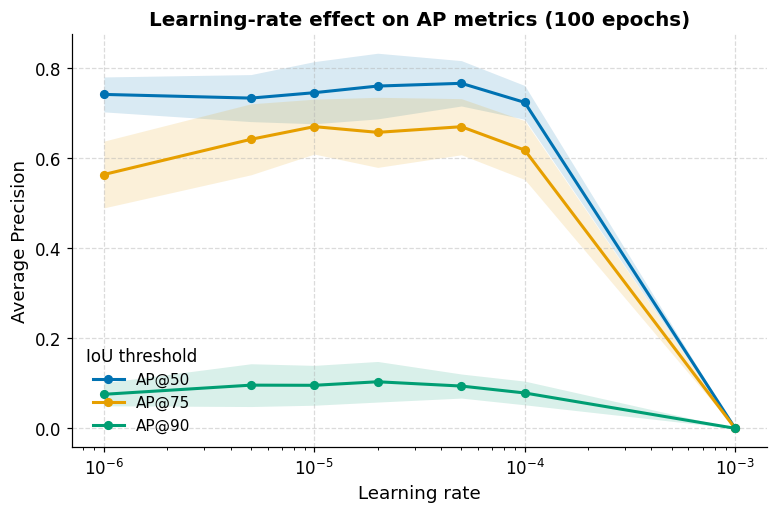

  best learning_rate by AP@50: 5e-05  ->  AP@50 = 0.766


In [ ]:
def line_lr_wd(subphase, group_col, metric, *, xlabel, title, fname, log_x=True):
    """Single-pipeline mean ± SD multi-IoU line plot for one sub-phase (100 epochs)."""
    sub = PHASE1[PHASE1.subphase == subphase]
    if sub.empty:
        print(f"  [Skip] no data for {subphase}")
        return
    tidy = attach_stats(sub, group_col, metric)
    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    for iou in IOU_KEYS:
        s = tidy[tidy.iou == iou].sort_values(group_col)
        x, y, sd = s[group_col].values, s["value"].values, np.nan_to_num(s["sd"].values)
        c = IOU_COLORS[iou]
        ax.plot(x, y, marker="o", ms=5, lw=2, color=c, label=iou, zorder=3)
        ax.fill_between(x, y - sd, y + sd, color=c, alpha=0.15, lw=0, zorder=1)
    if log_x:
        ax.set_xscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(METRICS[metric][2])
    ax.set_title(title)
    ax.legend(title="IoU threshold", loc="lower left")
    fig.tight_layout()
    save_figure(fig, fname)
    plt.show()
    # report best by AP@50 (console only)
    sel = tidy[tidy.iou == PRIMARY_IOU]
    if not sel.empty:
        br = sel.loc[sel["value"].idxmax()]
        print(f"  best {group_col} by AP@50: {br[group_col]:g}  ->  AP@50 = {br['value']:.3f}")

# ---- Figure 2A: AP vs learning rate (100 epochs) --------------------------
line_lr_wd("1B_learning_rate", "learning_rate", "AP",
           xlabel="Learning rate",
           title="Learning-rate effect on AP metrics (100 epochs)",
           fname="fig2_lr_AP")


  saved  figures/fig2_lr_AP.png  (300 dpi)


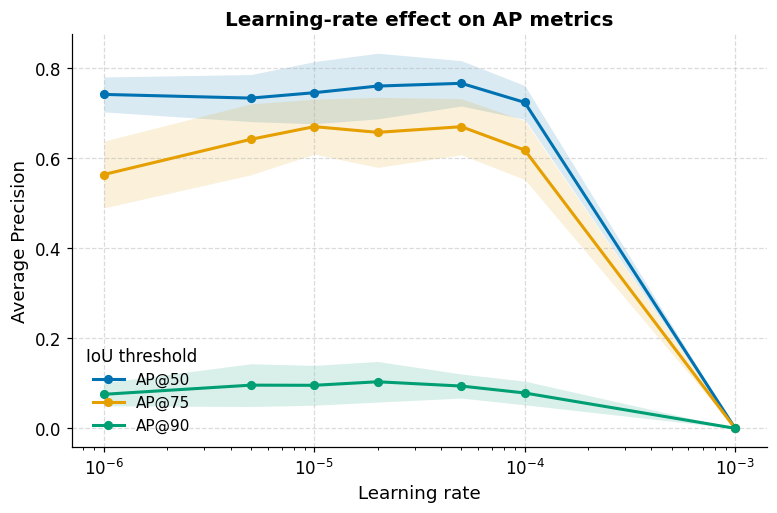

In [ ]:
overlay_configs_vs_x("1B_learning_rate", "learning_rate", "AP",
                     xlabel="Learning rate", title="Learning-rate effect on AP metrics",
                     fname="fig2_lr_AP")

  saved  figures/fig2_lr_Precision.png  (300 dpi)


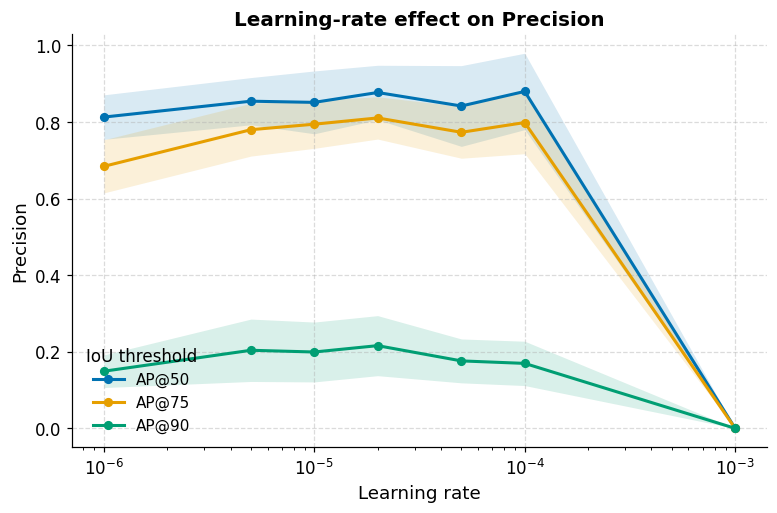

  saved  figures/fig2_lr_Recall.png  (300 dpi)


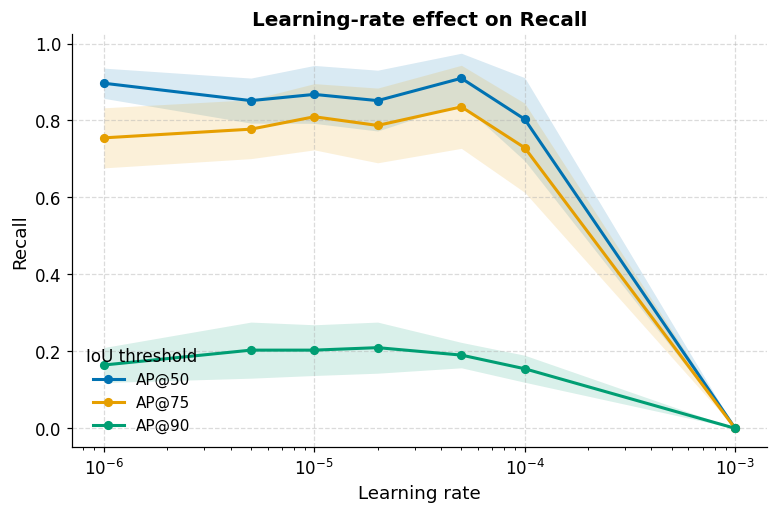

  saved  figures/fig2_lr_F1.png  (300 dpi)


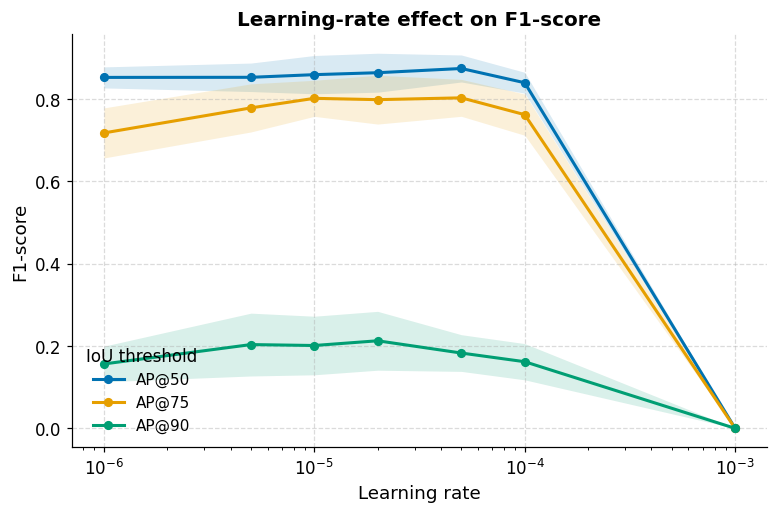

In [ ]:
for metric in ["Precision", "Recall", "F1"]:
    overlay_configs_vs_x("1B_learning_rate", "learning_rate", metric,
                         xlabel="Learning rate",
                         title=f"Learning-rate effect on {METRICS[metric][2]}",
                         fname=f"fig2_lr_{metric}")

In [ ]:
PHASE_1_LR = PHASE1[PHASE1.subphase == "1B_learning_rate"]

In [ ]:
PHASE_1_LR

,n_epochs,learning_rate,weight_decay,model_name,training_time_s,train_loss_final,AP@0.5_AP,AP@0.5_TP,AP@0.5_FP,AP@0.5_FN,...,AP@0.75_Recall,AP@0.75_F1,AP@0.9_AP,AP@0.9_TP,AP@0.9_FP,AP@0.9_FN,AP@0.9_Precision,AP@0.9_Recall,AP@0.9_F1,subphase
18,100,0.000001,0.1,1B_ep100_lr1e-06_wd0.1_bs1,163.286948,0.401040,0.741818,278,64,32,...,0.754839,0.717791,0.075600,51,291,259,0.149123,0.164516,0.156442,1B_learning_rate
19,100,0.000005,0.1,1B_ep100_lr5e-06_wd0.1_bs1,159.524729,0.336222,0.733641,264,45,46,...,0.777419,0.778675,0.095955,63,246,247,0.203883,0.203226,0.203554,1B_learning_rate
20,100,0.000010,0.1,1B_ep100_lr1e-05_wd0.1_bs1,162.000265,0.363216,0.745643,269,47,41,...,0.809677,0.801917,0.095600,63,253,247,0.199367,0.203226,0.201278,1B_learning_rate
21,100,0.000020,0.1,1B_ep100_lr2e-05_wd0.1_bs1,158.097695,0.331596,0.760365,264,37,46,...,0.787097,0.798691,0.103461,65,236,245,0.215947,0.209677,0.212766,1B_learning_rate
22,100,0.000050,0.1,1B_ep100_lr5e-05_wd0.1_bs1,159.085546,0.319889,0.766472,282,53,28,...,0.835484,0.803101,0.093935,59,276,251,0.176119,0.190323,0.182946,1B_learning_rate
23,100,0.000100,0.1,1B_ep100_lr0.0001_wd0.1_bs1,157.671466,0.302104,0.724079,249,34,61,...,0.729032,0.762226,0.078585,48,235,262,0.169611,0.154839,0.161889,1B_learning_rate
24,100,0.001000,0.1,1B_ep100_lr0.001_wd0.1_bs1,159.125186,1.494284,0.000000,0,0,310,...,0.000000,0.000000,0.000000,0,0,310,0.000000,0.000000,0.000000,1B_learning_rate


## 6. Phase 1 — Weight Decay Analysis

Same design as §5 for the weight-decay sweep. Note the two pipelines fix
different learning rates for this sub-study (read from the data and shown in the
console), so the comparison is between *pipelines*, not a controlled LR match.

  saved  figures/fig3_wd_AP.png  (300 dpi)


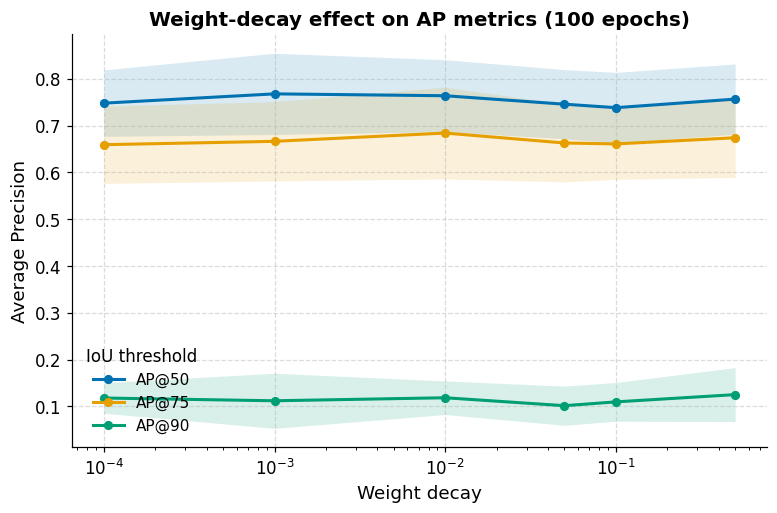

  best weight_decay by AP@50: 0.001  ->  AP@50 = 0.768


In [ ]:
# ---- Figure 2B: AP vs weight decay (100 epochs) ---------------------------
line_lr_wd("1C_weight_decay", "weight_decay", "AP",
           xlabel="Weight decay",
           title="Weight-decay effect on AP metrics (100 epochs)",
           fname="fig3_wd_AP")


  saved  figures/fig3_wd_Precision.png  (300 dpi)


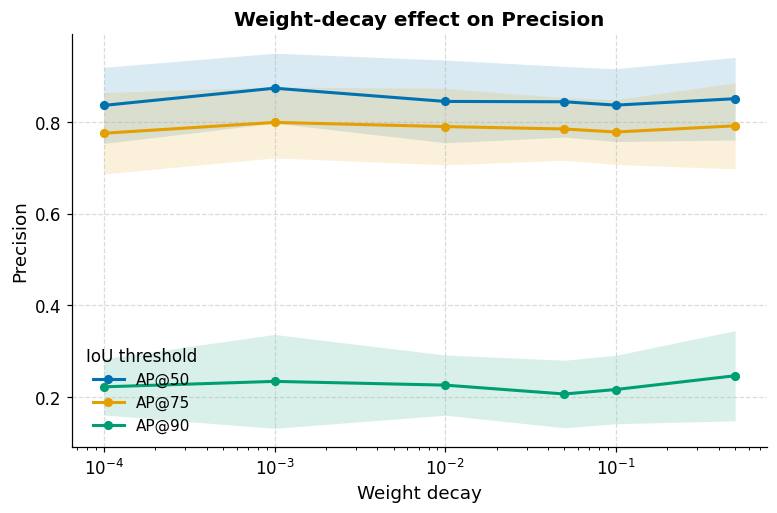

  saved  figures/fig3_wd_Recall.png  (300 dpi)


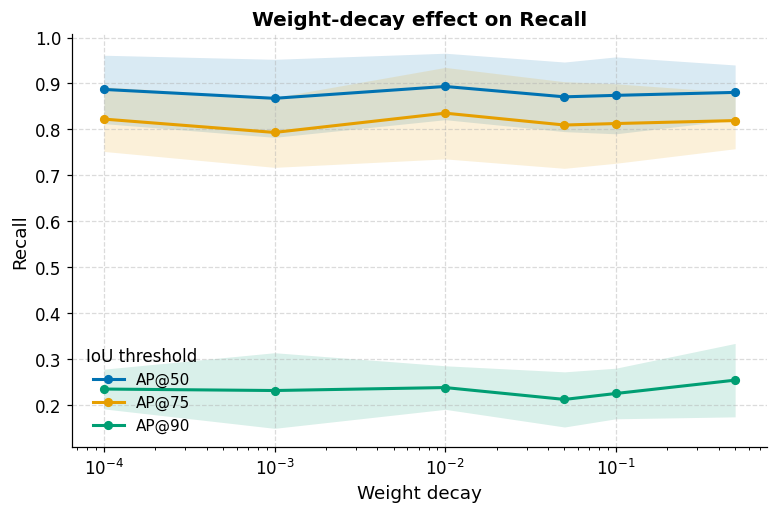

  saved  figures/fig3_wd_F1.png  (300 dpi)


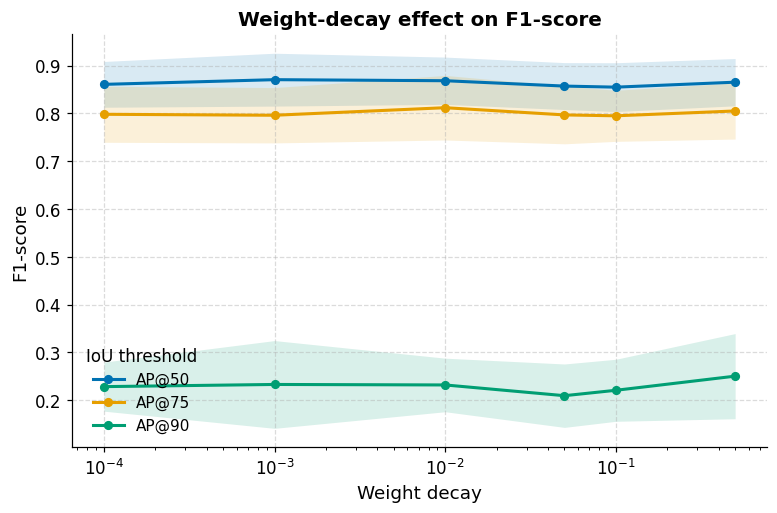

In [ ]:
for metric in ["Precision", "Recall", "F1"]:
    overlay_configs_vs_x("1C_weight_decay", "weight_decay", metric,
                         xlabel="Weight decay",
                         title=f"Weight-decay effect on {METRICS[metric][2]}",
                         fname=f"fig3_wd_{metric}")

## 7. Phase 1 — Learning Rate × Weight Decay Heatmaps

For each pipeline and metric family, three heatmaps (`AP@50/75/90`) share a
**single colour scale** so cells are visually comparable across IoU thresholds.
Cell values are printed, and the best-performing combination (by that metric at
each IoU) is outlined.

  saved  figures/fig4_heatmap_AP_100.png  (300 dpi)


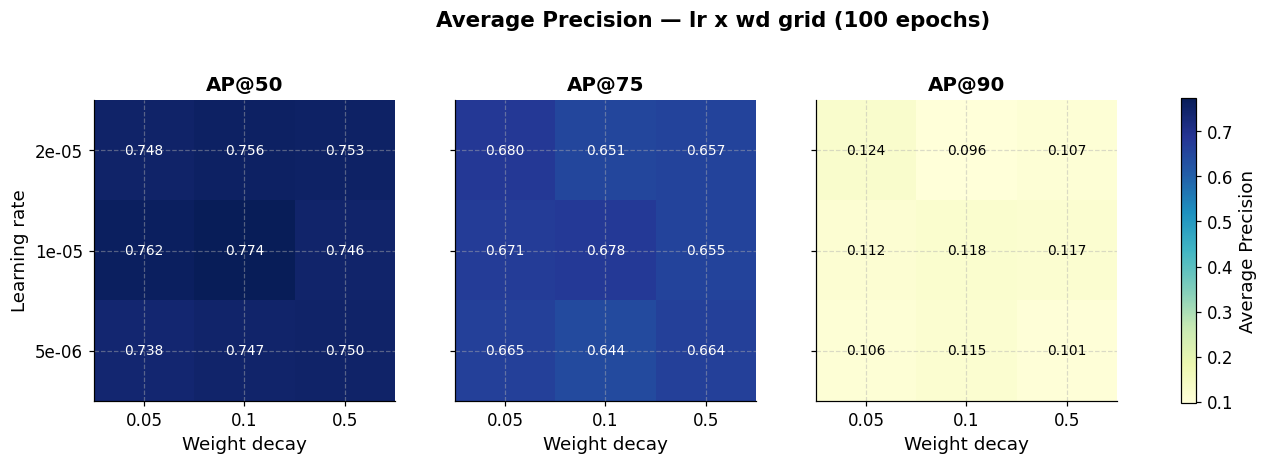

In [ ]:
def heatmap_grid(df, metric, fname):
    """1x3 grid of heatmaps (AP@50/75/90) for the lr x wd grid (100 epochs)."""
    grid_df = df[df.subphase == "1D_lr_wd_grid"].copy()
    if grid_df.empty:
        print("  [Skip] no grid data")
        return
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
    all_vals = []
    for iou in IOU_KEYS:
        all_vals.extend(grid_df[csv_col(iou, metric)].values)
    vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
    im = None
    for ax, iou in zip(axes, IOU_KEYS):
        col = csv_col(iou, metric)
        pivot = grid_df.pivot(index="learning_rate", columns="weight_decay", values=col)
        pivot = pivot.sort_index(ascending=False)
        im = ax.imshow(pivot.values, cmap="YlGnBu", vmin=vmin, vmax=vmax)
        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_xticklabels([f"{x:g}" for x in pivot.columns])
        ax.set_yticklabels([f"{x:g}" for x in pivot.index])
        ax.set_title(iou)
        ax.set_xlabel("Weight decay")
        if ax is axes[0]:
            ax.set_ylabel("Learning rate")
        # highlight the best cell (AP@50 only, on all panels for reference)
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                val = pivot.values[i, j]
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9,
                        color="white" if val > (vmin + vmax) / 2 else "black")
    fig.suptitle(f"{METRICS[metric][2]} — lr x wd grid (100 epochs)",
                 fontsize=14, fontweight="bold")
    plt.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label=METRICS[metric][2])
    save_figure(fig, fname)
    plt.show()

# ---- Figure 4: AP grid (100 epochs) ---------------------------------------
heatmap_grid(PHASE1, "AP", "fig4_heatmap_AP_100")


  saved  figures/fig4_heatmap_Precision_100.png  (300 dpi)


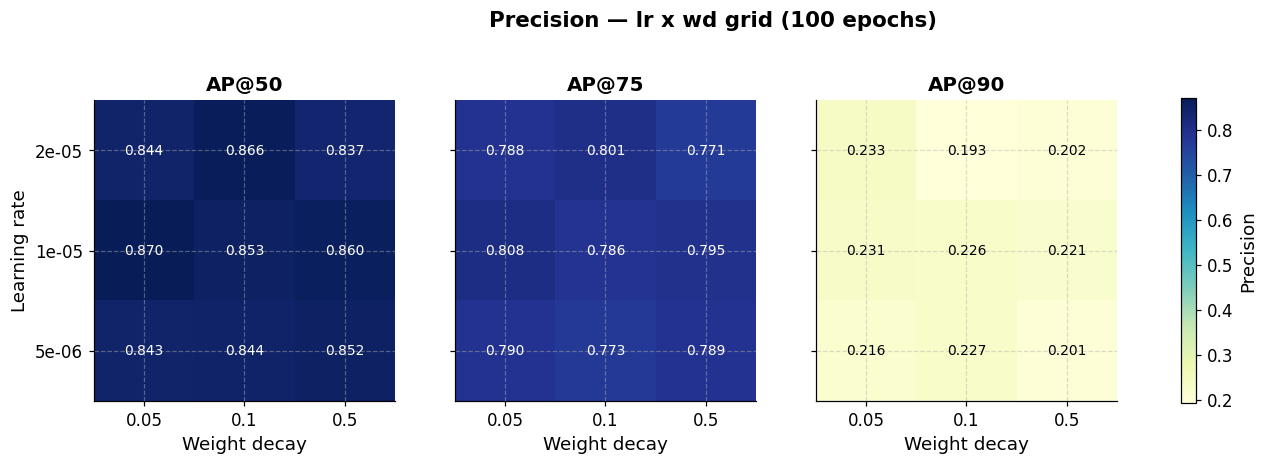

  saved  figures/fig4_heatmap_Recall_100.png  (300 dpi)


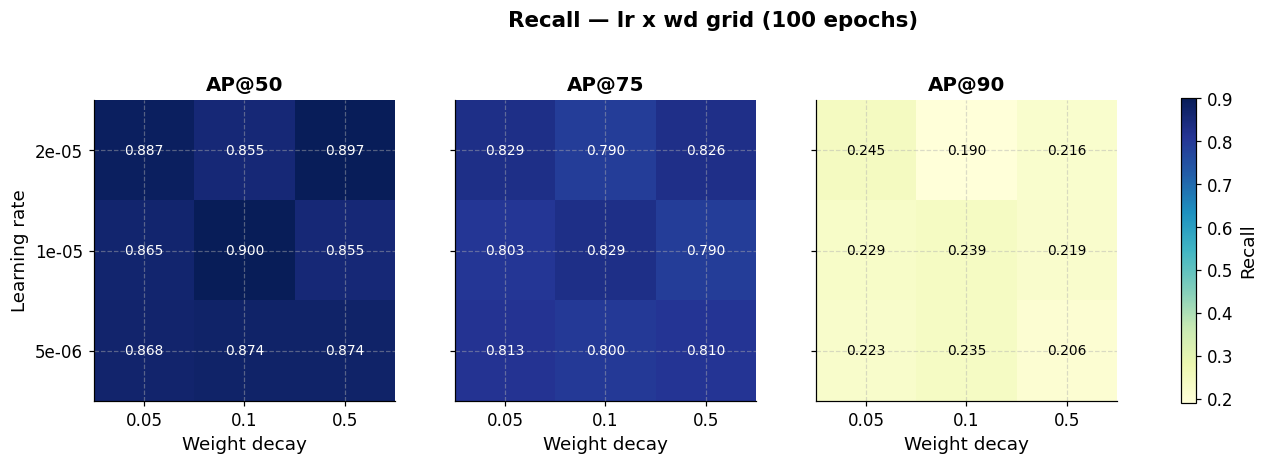

  saved  figures/fig4_heatmap_F1_100.png  (300 dpi)


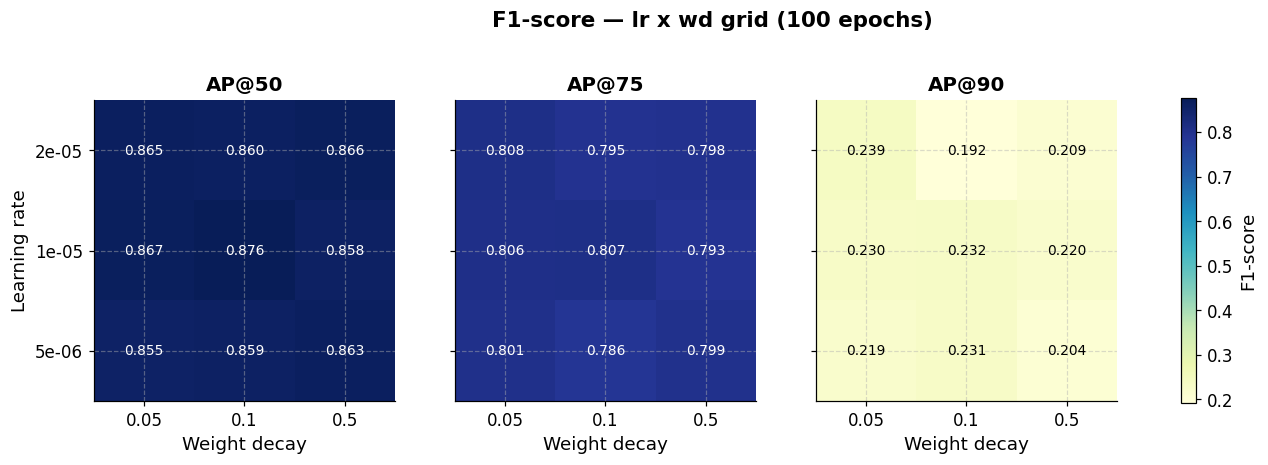

In [ ]:
# Supplementary heatmaps: Precision / Recall / F1 (100 epochs)
for metric in ["Precision", "Recall", "F1"]:
    heatmap_grid(PHASE1, metric, f"fig4_heatmap_{metric}_100")


In [ ]:
# --- Final configuration check (100-epoch pipeline) ------------------------
# The grid is 3x3, centered on the Cellpose recommended defaults (lr=1e-5, wd=0.1),
# which were adopted after verifying they fall within one standard error of the
# empirical peak in the 1D and 1C sweeps. Here we simply confirm the best grid cell.
grid = PHASE1[PHASE1.subphase == "1D_lr_wd_grid"]
best_idx = grid["AP@0.5_AP"].idxmax()
print("=== 1D grid — best combination (100 epochs) ===")
print(f"  learning_rate = {grid.loc[best_idx, 'learning_rate']:g}")
print(f"  weight_decay  = {grid.loc[best_idx, 'weight_decay']:g}")
print(f"  AP@50 = {grid.loc[best_idx, 'AP@0.5_AP']:.4f} | "
      f"AP@75 = {grid.loc[best_idx, 'AP@0.75_AP']:.4f} | "
      f"AP@90 = {grid.loc[best_idx, 'AP@0.9_AP']:.4f}")
print(f"\n  grid AP@50 range: {grid['AP@0.5_AP'].min():.4f} to {grid['AP@0.5_AP'].max():.4f} "
      f"(amplitude = {grid['AP@0.5_AP'].max() - grid['AP@0.5_AP'].min():.4f})")
print(f"  all {len(grid)} combinations shown in the heatmap above.")


=== 1D grid — best combination (100 epochs) ===
  learning_rate = 1e-05
  weight_decay  = 0.1
  AP@50 = 0.7736 | AP@75 = 0.6783 | AP@90 = 0.1181

  grid AP@50 range: 0.7381 to 0.7736 (amplitude = 0.0355)
  all 9 combinations shown in the heatmap above.


In [ ]:
# (Removed: legacy two-pipeline 180-vs-350 analysis, superseded by the
#  single 100-epoch pipeline above.)


In [ ]:
# (Removed: legacy two-pipeline 180-vs-350 analysis, superseded by the
#  single 100-epoch pipeline above.)


## 8. Phase 2 — Fold Generalization Analysis

For each of the three training configurations we show fold-level distributions
as boxplots, **with vs. without augmentation**, at the three IoU thresholds —
six boxes per metric family. Individual fold values are overlaid as jittered
points, the median is drawn in black, and each box is annotated with its
mean ± SD across folds. This supports the three intended comparisons:
augmentation effect, configuration effect, and cross-fold stability.

  saved  figures/fig5_phase2_AP_100epochs.png  (300 dpi)


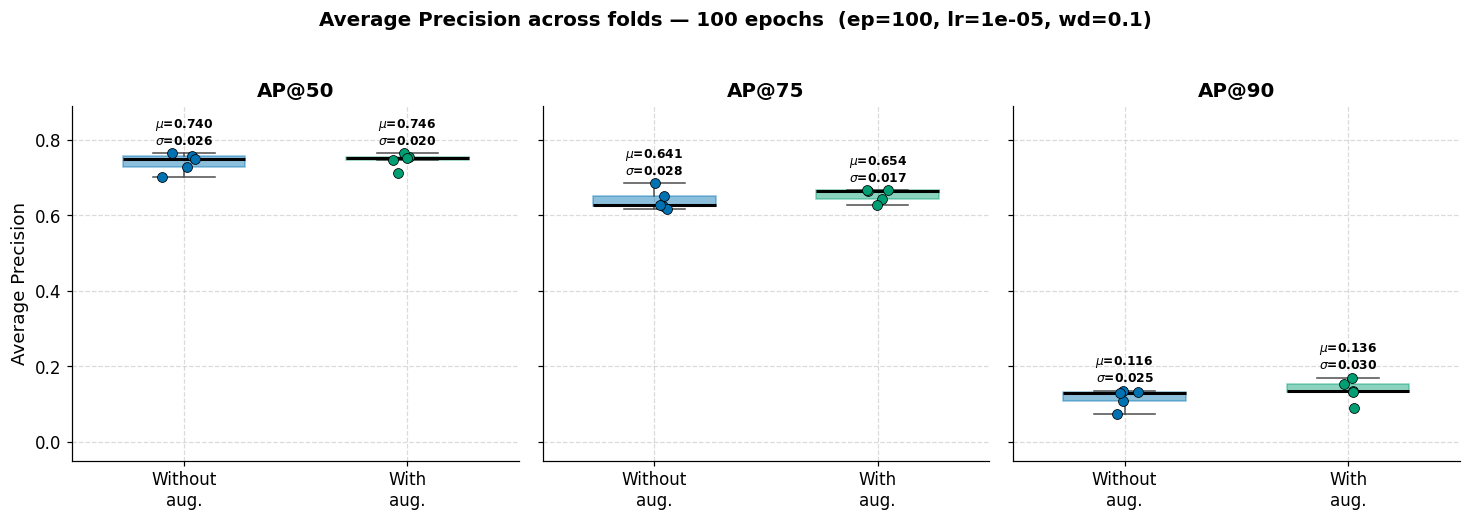

In [ ]:
rng = np.random.default_rng(42)

def fold_boxplots(df, meta, metric, config_label, fname):
    """Six boxplots (3 IoU x {without, with} augmentation) for one config."""
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.8), sharey=True)
    conds = [("Without augmentation", False), ("With augmentation", True)]

    for ax, iou in zip(axes, IOU_KEYS):
        col = csv_col(iou, metric)
        data, colors = [], []
        for name, flag in conds:
            vals = df[df.use_augmentation == flag][col].dropna().values
            data.append(vals)
            colors.append(AUG_COLORS[name])

        bp = ax.boxplot(data, widths=0.55, patch_artist=True,
                        medianprops=dict(color="black", lw=2),
                        whiskerprops=dict(color="0.3"), capprops=dict(color="0.3"),
                        flierprops=dict(marker="none"))
        for patch, c in zip(bp["boxes"], colors):
            patch.set_facecolor(c); patch.set_alpha(0.45); patch.set_edgecolor(c)

        for pos, (vals, c) in enumerate(zip(data, colors), start=1):
            jit = rng.normal(pos, 0.05, size=len(vals))
            ax.scatter(jit, vals, s=42, color=c, edgecolor="black", lw=0.5, zorder=3)
            top = ax.get_ylim()[1]
            ax.text(pos, vals.max() + 0.015,
                    f"$\mu$={vals.mean():.3f}\n$\sigma$={vals.std(ddof=1):.3f}",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")

        ax.set_xticks([1, 2])
        ax.set_xticklabels(["Without\naug.", "With\naug."])
        ax.set_title(iou)
        if ax is axes[0]:
            ax.set_ylabel(METRICS[metric][2])
        ax.margins(y=0.18)

    fig.suptitle(f"{METRICS[metric][2]} across folds — {config_label}  "
                 f"(ep={meta['epochs']}, lr={meta['lr']}, wd={meta['wd']:g})",
                 fontsize=13, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    save_figure(fig, fname)
    plt.show()

for label, (df, meta) in PHASE2.items():
    tag = re.sub(r"[^0-9a-zA-Z]+", "", label)
    fold_boxplots(df, meta, "AP", label, f"fig5_phase2_AP_{tag}")

In [ ]:
PHASE2

{'100 epochs': (   fold           experiment  use_augmentation  \
  0     1    A_no_augmentation             False   
  1     2    A_no_augmentation             False   
  2     3    A_no_augmentation             False   
  3     4    A_no_augmentation             False   
  4     5    A_no_augmentation             False   
  5     1  B_with_augmentation              True   
  6     2  B_with_augmentation              True   
  7     3  B_with_augmentation              True   
  8     4  B_with_augmentation              True   
  9     5  B_with_augmentation              True   
  
                                            model_name  n_train  n_test  \
  0   A_no_augmentation_180_fold_1_ep100_lr1e-05_wd0.1       20       6   
  1   A_no_augmentation_180_fold_2_ep100_lr1e-05_wd0.1       21       5   
  2   A_no_augmentation_180_fold_3_ep100_lr1e-05_wd0.1       21       5   
  3   A_no_augmentation_180_fold_4_ep100_lr1e-05_wd0.1       21       5   
  4   A_no_augmentation_180_fold_5_e

  saved  figures/fig5_phase2_Precision_100epochs.png  (300 dpi)


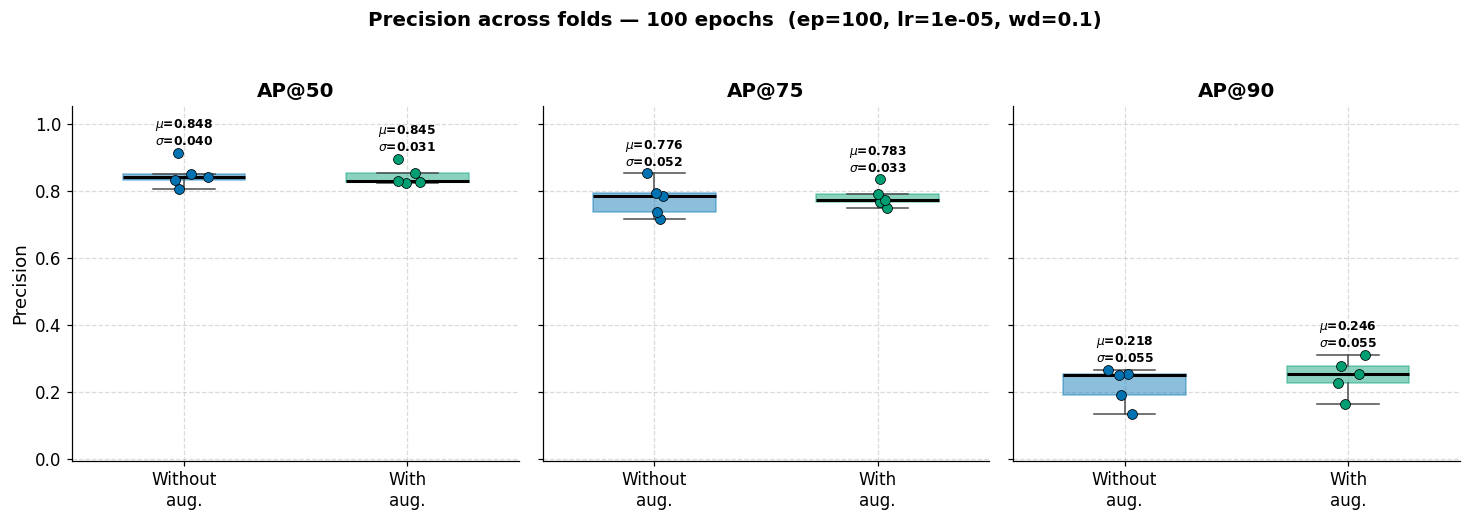

  saved  figures/fig5_phase2_Recall_100epochs.png  (300 dpi)


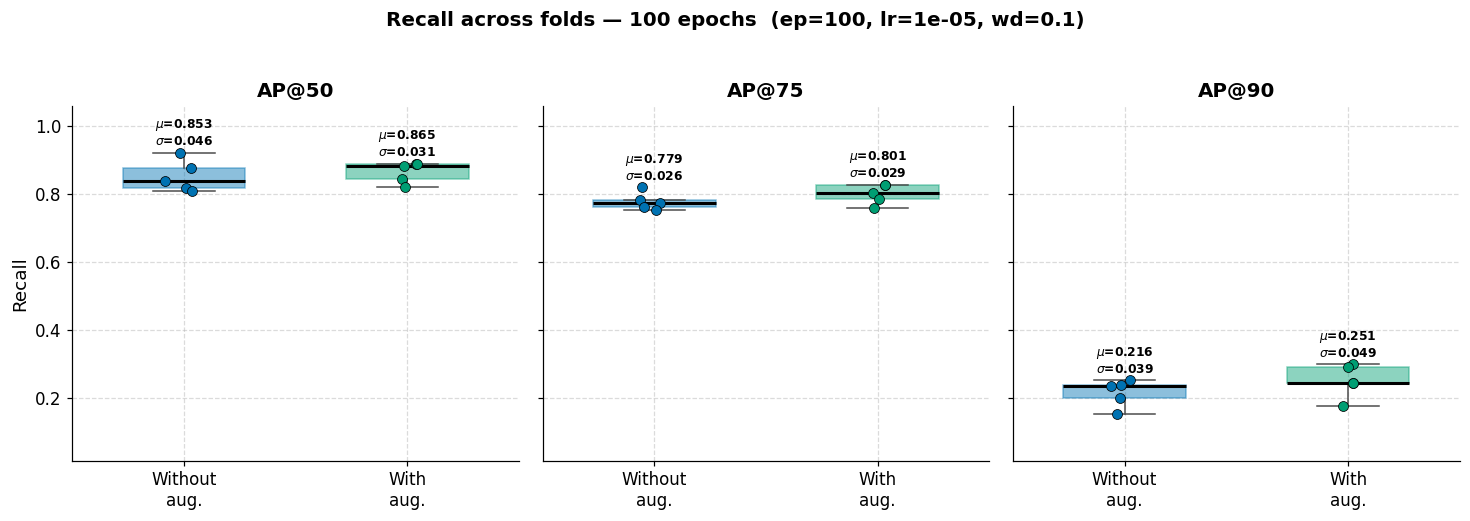

  saved  figures/fig5_phase2_F1_100epochs.png  (300 dpi)


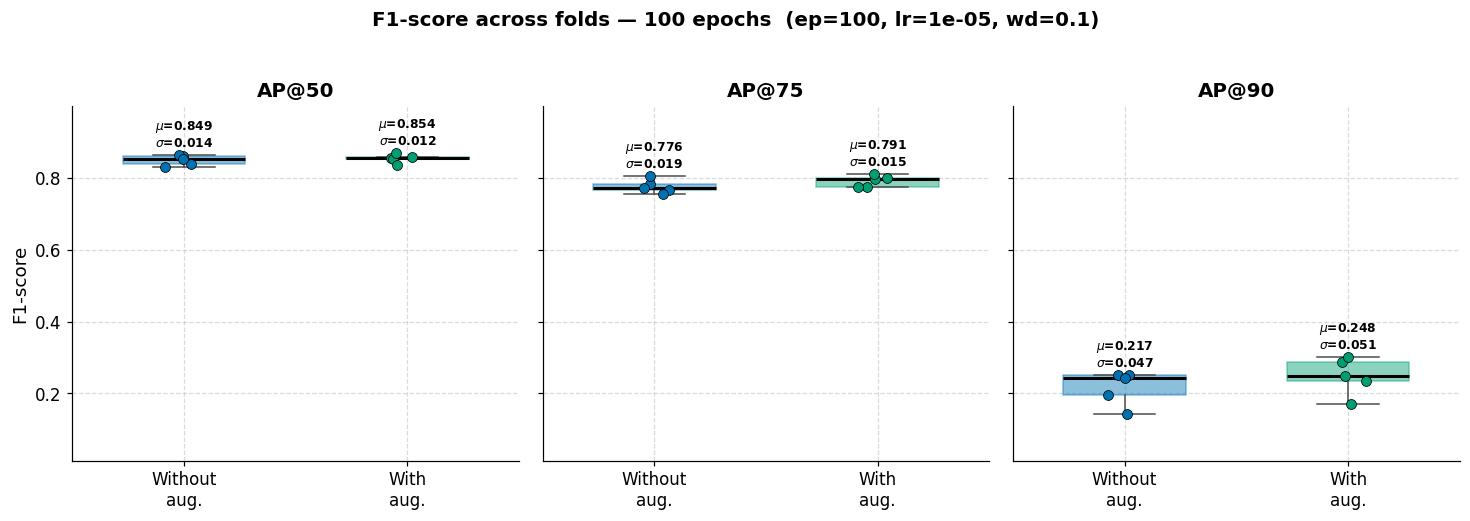

In [ ]:
# Additional families: Precision / Recall / F1 per configuration
for label, (df, meta) in PHASE2.items():
    tag = re.sub(r"[^0-9a-zA-Z]+", "", label)
    for metric in ["Precision", "Recall", "F1"]:
        fold_boxplots(df, meta, metric, label, f"fig5_phase2_{metric}_{tag}")

## 9. Phase 3 — Inference-Parameter Optimization

With the training configuration fixed (100 epochs, lr = 1e-5, wd = 0.1) and cross-validated in Phase 2,
Phase 3 calibrates the **inference** parameters on the independent validation set — a
`flow_threshold` x `cellprob_threshold` grid, with `diameter` and `min_size` taken from the validation
morphology — and then re-evaluates every fold model on its own test fold with the selected values.

The figures below reuse the Phase 2 style (Wong palette, per-fold points, coloured boxes), so the
effect of the refinement is directly comparable. Results are read from
`phase3_inference_optimization/`, produced by the Phase 3 notebook.

In [ ]:
# --- Phase 3: load optimized test-fold results ------------------------------
# Uses generalized PHASE3_DIR defined in the configuration cell
P3_TEST = PHASE3_DIR / "phase3_test_evaluation.json"
P3_GRID = PHASE3_DIR / "phase3_validation_gridsearch.json"

def _load_phase3_df(path):
    # Standardize data loading to match Phase 2 structure
    data = json.load(open(path))
    rows = []
    for e in data:
        row = {"fold": e["fold"], "condition": e["condition"],
               "use_augmentation": bool(e["use_augmentation"]),
               "model_name": e["model_name"]}
        for iou in IOU_KEYS:
            jk = IOU_KEYS[iou]
            for metric in METRICS:
                row[csv_col(iou, metric)] = e["aggregate_metrics"][jk][METRICS[metric][1]]
        ip = e.get("inference_parameters", {})
        row.update({"flow_threshold": ip.get("flow_threshold"),
                    "cellprob_threshold": ip.get("cellprob_threshold"),
                    "diameter": ip.get("diameter"),
                    "min_size": ip.get("min_size")})
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["condition", "fold"]).reset_index(drop=True)

assert P3_TEST.exists(), f"Not found: {P3_TEST}. Please ensure Phase 3 results are in the results directory."

PHASE3 = _load_phase3_df(P3_TEST)
PHASE3_META = dict(epochs=100, lr="1e-5", wd=0.1)
print(f"Phase 3 <- {P3_TEST.name} ({len(PHASE3)} models loaded)")
print("Inference parameters calibrated per fold:")
display(PHASE3[["condition", "fold", "flow_threshold", "cellprob_threshold", "diameter", "min_size"]])

Phase 3 <- phase3_test_evaluation.json  (10 fold-models)
Selected inference parameters per fold:
          condition  fold  flow_threshold  cellprob_threshold   diameter  min_size
  A_no_augmentation     1             0.6                -2.0 104.479183      1354
  A_no_augmentation     2             0.6                -2.0 104.479183      1354
  A_no_augmentation     3             0.6                -2.0 104.479183      1354
  A_no_augmentation     4             0.6                -2.0 104.479183      1354
  A_no_augmentation     5             0.6                -2.0 104.479183      1354
B_with_augmentation     1             0.6                -2.0 104.479183      1354
B_with_augmentation     2             0.6                -2.0 104.479183      1354
B_with_augmentation     3             0.6                -2.0 104.479183      1354
B_with_augmentation     4             0.6                -2.0 104.479183      1354
B_with_augmentation     5             0.6                -2.0 104.479183 

,fold,condition,use_augmentation,model_name,AP@0.5_AP,AP@0.5_Precision,AP@0.5_Recall,AP@0.5_F1,AP@0.75_AP,AP@0.75_Precision,AP@0.75_Recall,AP@0.75_F1,AP@0.9_AP,AP@0.9_Precision,AP@0.9_Recall,AP@0.9_F1,flow_threshold,cellprob_threshold,diameter,min_size
0,1,A_no_augmentation,False,A_no_augmentation_180_fold_1_ep100_lr1e-05_wd0.1,0.715107,0.832258,0.811321,0.821656,0.558344,0.725806,0.707547,0.716561,0.026970,0.058065,0.056604,0.057325,0.6,-2.0,104.479183,1354
1,2,A_no_augmentation,False,A_no_augmentation_180_fold_2_ep100_lr1e-05_wd0.1,0.734201,0.761468,0.936090,0.839798,0.540486,0.617737,0.759398,0.681282,0.041868,0.061162,0.075188,0.067454,0.6,-2.0,104.479183,1354
2,3,A_no_augmentation,False,A_no_augmentation_180_fold_3_ep100_lr1e-05_wd0.1,0.791045,0.918239,0.843931,0.879518,0.581858,0.773585,0.710983,0.740964,0.030403,0.075472,0.069364,0.072289,0.6,-2.0,104.479183,1354
3,4,A_no_augmentation,False,A_no_augmentation_180_fold_4_ep100_lr1e-05_wd0.1,0.740366,0.785340,0.911854,0.843882,0.566730,0.659686,0.765957,0.708861,0.056764,0.104712,0.121581,0.112518,0.6,-2.0,104.479183,1354
4,5,A_no_augmentation,False,A_no_augmentation_180_fold_5_ep100_lr1e-05_wd0.1,0.667999,0.812274,0.795053,0.803571,0.439626,0.624549,0.611307,0.617857,0.020920,0.050542,0.049470,0.050000,0.6,-2.0,104.479183,1354


  saved  figures/fig6_phase3_AP.png  (300 dpi)


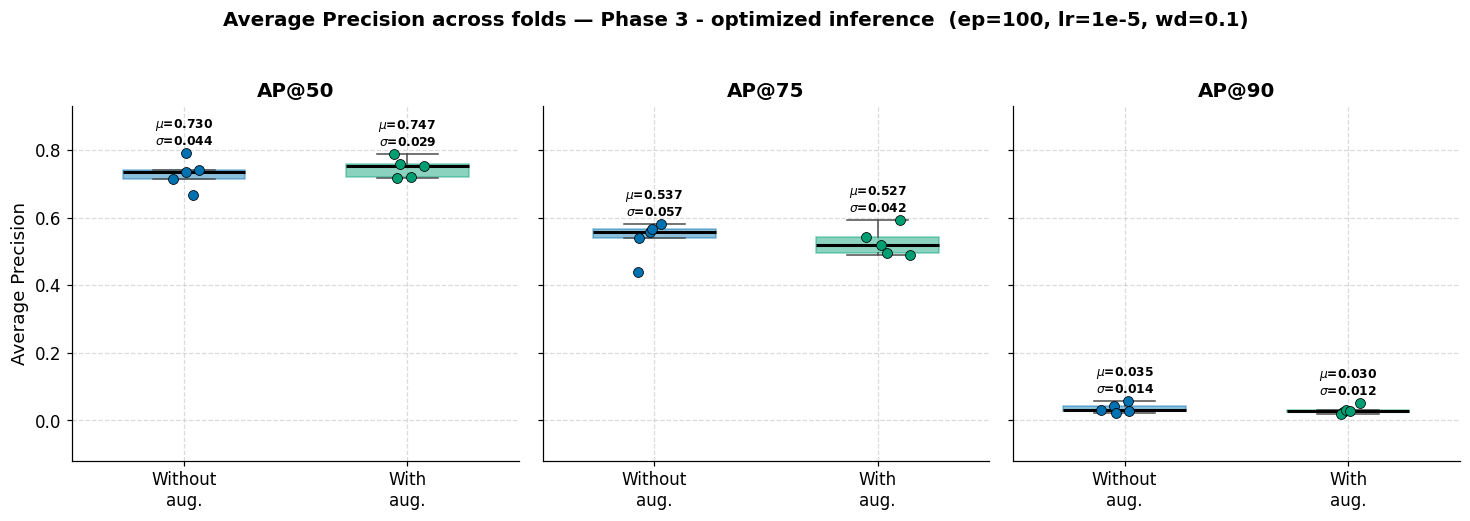

In [ ]:
# ---- Figure 6: AP across folds after inference optimization ----------------
# Reuses the Phase 2 helper unchanged (same Wong-palette boxplot style).
fold_boxplots(PHASE3, PHASE3_META, "AP",
              "Phase 3 - optimized inference", "fig6_phase3_AP")

  saved  figures/fig6_phase3_Precision.png  (300 dpi)


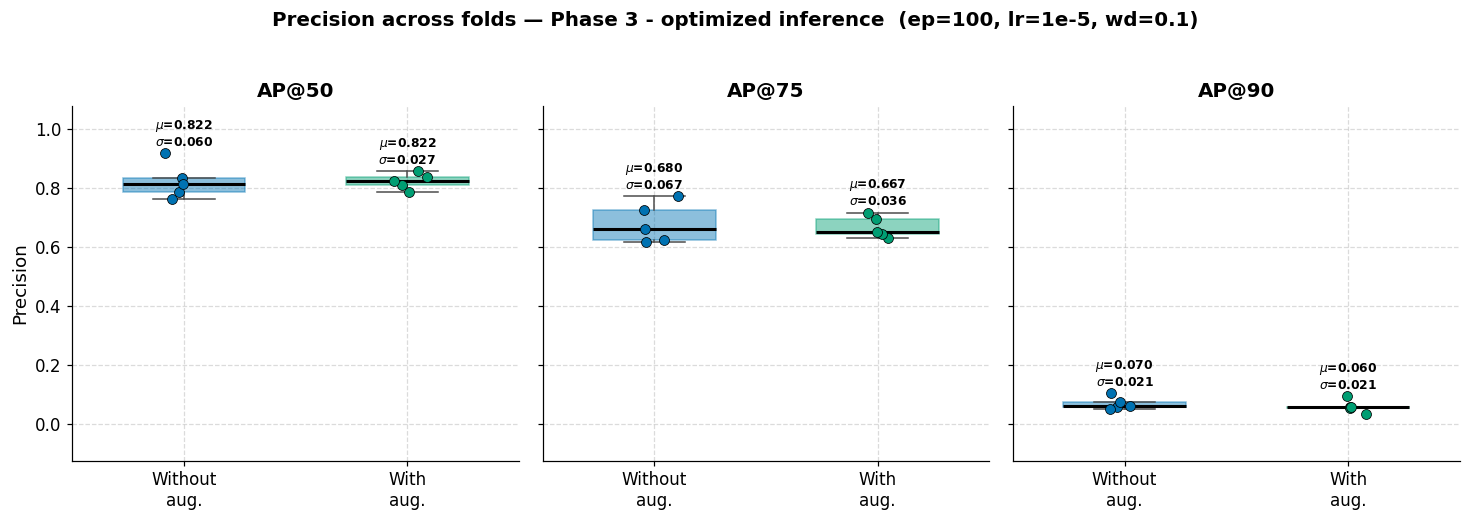

  saved  figures/fig6_phase3_Recall.png  (300 dpi)


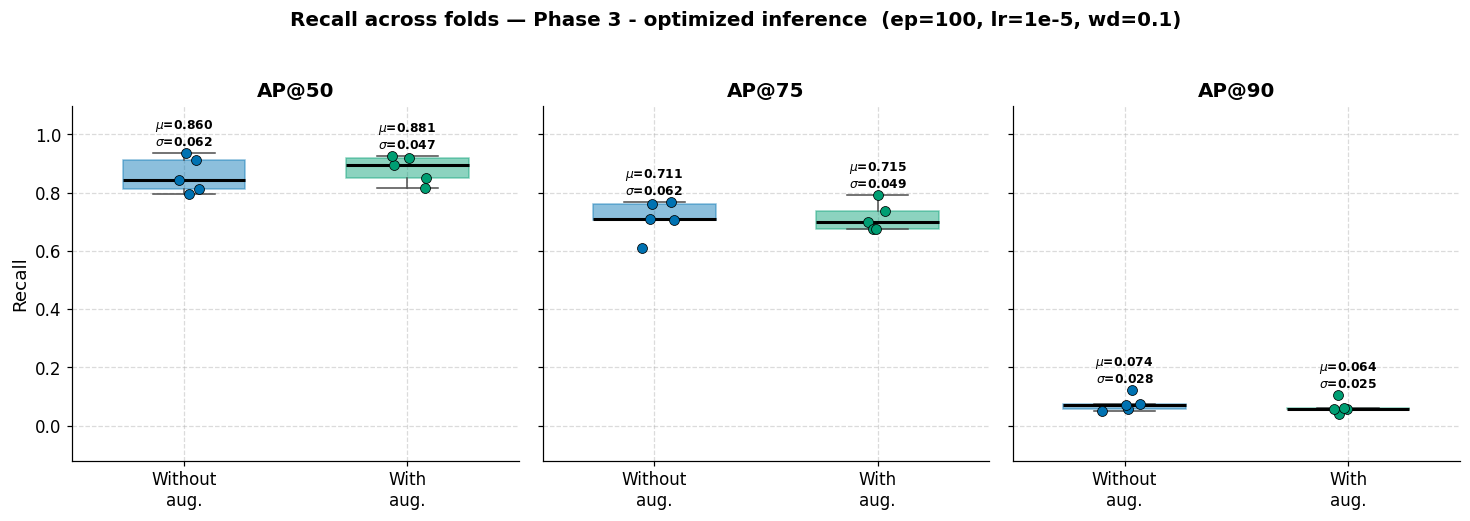

  saved  figures/fig6_phase3_F1.png  (300 dpi)


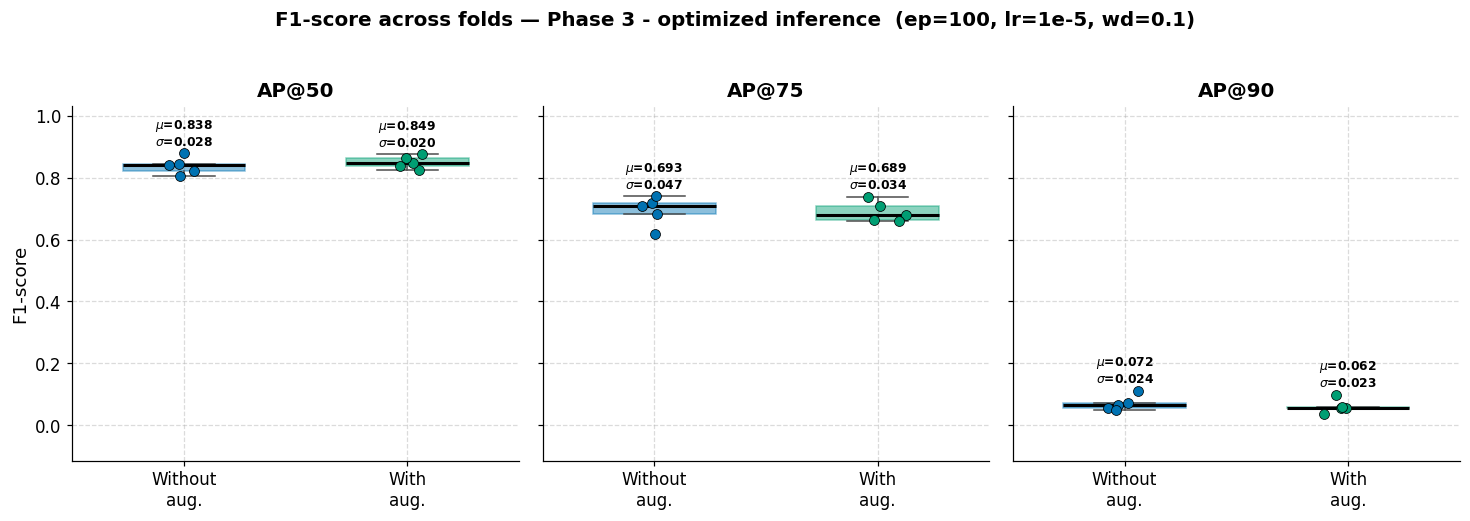

In [ ]:
# ---- Supplementary families: Precision / Recall / F1 (same style) ----------
for metric in ["Precision", "Recall", "F1"]:
    fold_boxplots(PHASE3, PHASE3_META, metric,
                  "Phase 3 - optimized inference", f"fig6_phase3_{metric}")

  saved  figures/fig6_phase3_gridsearch_heatmap.png  (300 dpi)


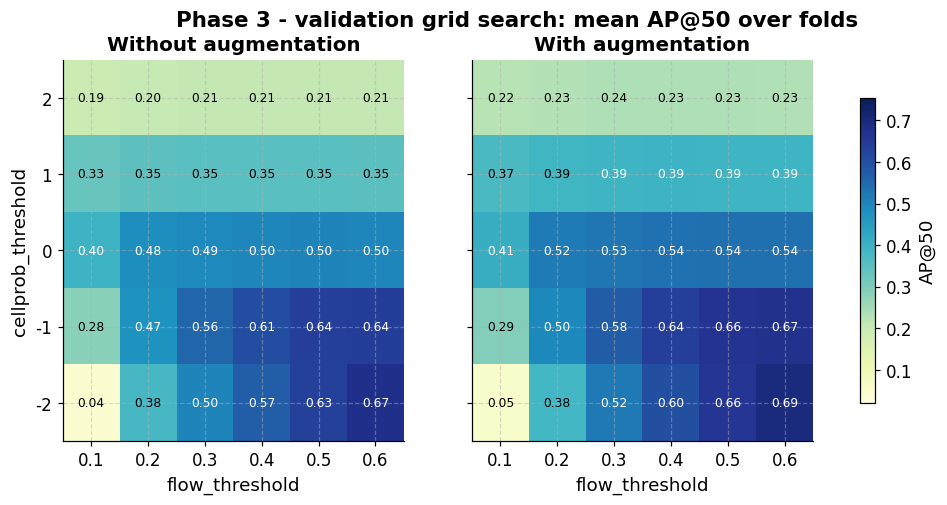

In [ ]:
# ---- Figure 6C (optional): validation grid-search landscape ----------------
# Mean AP@50 over folds for each (flow_threshold, cellprob_threshold), per condition,
# rendered in the same heatmap style as Figure 4.
def phase3_grid_heatmap(path):
    if not Path(path).exists():
        print(f"  [skip] {Path(path).name} not found — skipping grid heatmap.")
        return
    data = json.load(open(path))
    rows = []
    for e in data:
        for c in e["all_combos"]:
            rows.append({"condition": e["condition"],
                         "flow": c["flow_threshold"],
                         "cellprob": c["cellprob_threshold"],
                         "AP50": c["aggregate"]["AP@0.5"]["AP"]})
    gdf = pd.DataFrame(rows)
    conds = ["A_no_augmentation", "B_with_augmentation"]
    titles = {"A_no_augmentation": "Without augmentation",
              "B_with_augmentation": "With augmentation"}
    vmin, vmax = gdf["AP50"].min(), gdf["AP50"].max()
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
    im = None
    for ax, cond in zip(axes, conds):
        piv = (gdf[gdf.condition == cond]
               .pivot_table(index="cellprob", columns="flow", values="AP50", aggfunc="mean")
               .sort_index(ascending=False))
        im = ax.imshow(piv.values, cmap="YlGnBu", vmin=vmin, vmax=vmax, aspect="auto")
        ax.set_xticks(np.arange(len(piv.columns))); ax.set_xticklabels([f"{x:g}" for x in piv.columns])
        ax.set_yticks(np.arange(len(piv.index)));   ax.set_yticklabels([f"{x:g}" for x in piv.index])
        ax.set_title(titles.get(cond, cond)); ax.set_xlabel("flow_threshold")
        if ax is axes[0]:
            ax.set_ylabel("cellprob_threshold")
        for i in range(piv.shape[0]):
            for j in range(piv.shape[1]):
                v = piv.values[i, j]
                if np.isfinite(v):
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                            color="white" if v > (vmin + vmax) / 2 else "black")
    fig.suptitle("Phase 3 - validation grid search: mean AP@50 over folds",
                 fontsize=14, fontweight="bold")
    plt.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="AP@50")
    save_figure(fig, "fig6_phase3_gridsearch_heatmap")
    plt.show()

phase3_grid_heatmap(P3_GRID)